# NASA PCoE Battery Dataset

### Chemistry: Lithium-Ion (Li-ion)

**Source:** NASA Ames Prognostics Center of Excellence (PCoE)

**Objective:** State of Charge (SOC) Estimation using Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) Networks.

---

## Introduction

Accurate estimation of Battery State of Charge (SOC) is a critical requirement for Battery Management Systems (BMS) used in electric vehicles, renewable energy storage systems, and portable electronic devices. SOC represents the remaining available charge in a battery and directly influences system performance, safety, and reliability.

The NASA Prognostics Center of Excellence (PCoE) Battery Dataset is one of the most widely used benchmark datasets for battery health monitoring, prognostics, and machine learning research. The dataset contains measurements collected from multiple lithium-ion batteries subjected to repeated charge and discharge cycles under controlled laboratory conditions.

The dataset provides detailed battery operating parameters such as voltage, current, temperature, capacity, and cycle information, making it suitable for developing data-driven SOC estimation models.

In this study, the NASA PCoE dataset is used to develop deep learning models for SOC prediction. Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) networks are employed to learn the temporal behaviour of battery charge-discharge characteristics and estimate SOC from measured battery parameters.

---

## Dataset Information

| Attribute    | Description                               |
| ------------ | ----------------------------------------- |
| Dataset      | NASA PCoE Battery Dataset                 |
| Battery Type | Lithium-Ion                               |
| Application  | Battery Prognostics and Health Monitoring |
| Inputs       | Voltage, Current, Temperature             |
| Target       | State of Charge (SOC)                     |
| Models       | LSTM, GRU                                 |

---

## Workflow

1. Dataset Loading and Inspection
2. Data Preprocessing
3. SOC Calculation
4. Feature Selection
5. Data Normalization
6. Sequence Generation
7. Train-Test Split
8. LSTM Training
9. GRU Training
10. Performance Evaluation
11. Comparative Analysis

---

## Expected Outcome

The objective is to evaluate the effectiveness of LSTM and GRU architectures for SOC estimation on the NASA lithium-ion battery dataset and compare their performance with other battery chemistries, including NCA and LFP datasets analyzed in previous experiments.


In [31]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
import requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

In [3]:
import zipfile

zip_path = r"C:\Users\shrij\Downloads\5.+Battery+Data+Set.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(r"C:\NASA")

print("NASA Dataset Extracted Successfully!")

NASA Dataset Extracted Successfully!


In [4]:
import os

for root, dirs, files in os.walk(r"C:\NASA"):
    for file in files:
        print(os.path.join(root, file))

C:\NASA\5. Battery Data Set\1. BatteryAgingARC-FY08Q4.zip
C:\NASA\5. Battery Data Set\2. BatteryAgingARC_25_26_27_28_P1.zip
C:\NASA\5. Battery Data Set\3. BatteryAgingARC_25-44.zip
C:\NASA\5. Battery Data Set\4. BatteryAgingARC_45_46_47_48.zip
C:\NASA\5. Battery Data Set\5. BatteryAgingARC_49_50_51_52.zip
C:\NASA\5. Battery Data Set\6. BatteryAgingARC_53_54_55_56.zip


In [5]:
import zipfile
import os

source_folder = r"C:\NASA\5. Battery Data Set"
extract_folder = r"C:\NASA\Extracted"

os.makedirs(extract_folder, exist_ok=True)

for file in os.listdir(source_folder):

    if file.endswith(".zip"):

        zip_file = os.path.join(source_folder, file)

        folder_name = os.path.splitext(file)[0]

        target = os.path.join(extract_folder, folder_name)

        os.makedirs(target, exist_ok=True)

        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(target)

        print("Extracted:", file)

Extracted: 1. BatteryAgingARC-FY08Q4.zip
Extracted: 2. BatteryAgingARC_25_26_27_28_P1.zip
Extracted: 3. BatteryAgingARC_25-44.zip
Extracted: 4. BatteryAgingARC_45_46_47_48.zip
Extracted: 5. BatteryAgingARC_49_50_51_52.zip
Extracted: 6. BatteryAgingARC_53_54_55_56.zip


In [6]:
import os

for root, dirs, files in os.walk(r"C:\NASA\Extracted"):

    for file in files:

        if file.endswith(".mat"):
            print(os.path.join(root, file))

C:\NASA\Extracted\1. BatteryAgingARC-FY08Q4\B0005.mat
C:\NASA\Extracted\1. BatteryAgingARC-FY08Q4\B0006.mat
C:\NASA\Extracted\1. BatteryAgingARC-FY08Q4\B0007.mat
C:\NASA\Extracted\1. BatteryAgingARC-FY08Q4\B0018.mat
C:\NASA\Extracted\2. BatteryAgingARC_25_26_27_28_P1\B0025.mat
C:\NASA\Extracted\2. BatteryAgingARC_25_26_27_28_P1\B0026.mat
C:\NASA\Extracted\2. BatteryAgingARC_25_26_27_28_P1\B0027.mat
C:\NASA\Extracted\2. BatteryAgingARC_25_26_27_28_P1\B0028.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0025.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0026.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0027.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0028.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0029.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0030.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0031.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0032.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0033.mat
C:\NASA\Extracted\3. BatteryAgingARC_25-44\B0034.mat
C:\NAS

### Dataset Inspection

The NASA PCoE Battery Dataset contains multiple lithium-ion batteries subjected to repeated charge-discharge cycles under controlled laboratory conditions.

The dataset is stored in MATLAB (.mat) format and contains cycle-wise measurements of battery voltage, current, temperature, and capacity information.

For this study, one representative battery cell will be analyzed to develop and evaluate LSTM and GRU models for SOC estimation.

In [7]:
from scipy.io import loadmat

mat = loadmat(
    r"C:\NASA\Extracted\1. BatteryAgingARC-FY08Q4\B0005.mat"
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


In [8]:
battery = mat['B0005']

print(type(battery))
print(battery.shape)

<class 'numpy.ndarray'>
(1, 1)


In [9]:
print(battery.dtype)


[('cycle', 'O')]


### Cycle Data Extraction

The NASA battery file contains cycle-wise operational information stored within a MATLAB structure.

The cycle field contains charge, discharge, and impedance measurements recorded throughout the battery lifetime. These cycle records will be inspected to identify the parameters required for SOC estimation.

In [10]:
cycle = battery['cycle'][0,0]

print(type(cycle))
print(cycle.shape)
print(cycle.dtype)

<class 'numpy.ndarray'>
(1, 616)
[('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]


### Cycle Structure Analysis

The NASA PCoE Battery Dataset contains multiple lithium-ion battery cells subjected to repeated charge-discharge cycling under controlled laboratory conditions.

Each battery file contains cycle-wise information including charge, discharge, and impedance measurements. The dataset structure consists of:

* Cycle Type
* Ambient Temperature
* Time Information
* Measurement Data

The measurement data includes battery operational parameters such as voltage, current, temperature, and capacity recorded during cycling.

For dataset exploration, Battery B0005 was initially inspected to understand the internal MATLAB file structure. After identifying the required measurement parameters and data organization, all available battery cells will be incorporated into the final SOC estimation dataset to improve model generalization and robustness.

### Input Features

The following battery measurements will be used as input features:

* Voltage (V)
* Current (A)
* Temperature (°C)

### Target Variable

* State of Charge (SOC)

### Deep Learning Models

* Long Short-Term Memory (LSTM)
* Gated Recurrent Unit (GRU)

The objective is to train the models using data collected from multiple lithium-ion batteries and evaluate their ability to estimate SOC under varying operating conditions.


In [14]:
print(type(data_field[0]))

try:
    print(data_field[0].dtype)
except:
    pass

try:
    print(data_field[0].shape)
except:
    pass

<class 'numpy.ndarray'>
[('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_charge', 'O'), ('Voltage_charge', 'O'), ('Time', 'O')]
(1, 1)


In [15]:
cycle_types = cycle['type'][0]

print("Number of cycles:", len(cycle_types))

for i in range(5):
    print(i, cycle_types[i])

Number of cycles: 616
0 ['charge']
1 ['discharge']
2 ['charge']
3 ['discharge']
4 ['charge']


## Feature Identification

Inspection of the cycle data revealed the following battery measurements:

- Voltage_measured (V)
- Current_measured (A)
- Temperature_measured (°C)
- Current_charge (A)
- Voltage_charge (V)
- Time (s)

For SOC estimation, the following input features will be used:

1. Voltage_measured
2. Current_measured
3. Temperature_measured

The target variable (SOC) will be derived from battery discharge capacity information.

In [17]:
discharge_idx = 1

sample = data_field[discharge_idx]

print(sample.dtype.names)

('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')


In [18]:
for field in sample.dtype.names:
    print(field)

Voltage_measured
Current_measured
Temperature_measured
Current_load
Voltage_load
Time
Capacity


###  Discharge Cycle Analysis

SOC estimation is performed using discharge cycle data because battery capacity information is available during discharge operations.

The discharge cycle measurements are inspected to identify capacity values required for SOC calculation.

In [19]:
sample = data_field[1]

print(sample.dtype.names)

('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')


#### Feature Extraction

The discharge cycle data contains several battery measurements recorded during battery operation.

The following parameters were identified:

- Voltage_measured (V)
- Current_measured (A)
- Temperature_measured (°C)
- Current_load (A)
- Voltage_load (V)
- Time (s)
- Capacity (Ah)

For SOC estimation, the following input features will be used:

1. Voltage_measured
2. Current_measured
3. Temperature_measured

The target variable (SOC) will be derived using discharge capacity information.

The complete NASA dataset containing multiple lithium-ion battery cells will be utilized to improve model robustness and generalization.

In [20]:
sample = data_field[1]

for field in sample.dtype.names:
    print(field)

print("\nCapacity:")
print(sample['Capacity'])

Voltage_measured
Current_measured
Temperature_measured
Current_load
Voltage_load
Time
Capacity

Capacity:
[[array([[1.85648742]])]]


In [21]:
sample = data_field[1]

print("Voltage Shape:",
      sample['Voltage_measured'][0,0].shape)

print("Current Shape:",
      sample['Current_measured'][0,0].shape)

print("Temperature Shape:",
      sample['Temperature_measured'][0,0].shape)

Voltage Shape: (1, 197)
Current Shape: (1, 197)
Temperature Shape: (1, 197)


In [22]:
sample = data_field[1]

print(sample['Voltage_measured'][0,0][:5])

print(sample['Current_measured'][0,0][:5])

print(sample['Temperature_measured'][0,0][:5])

print(sample['Capacity'])

[[4.19149181 4.19074907 3.97487091 3.95171671 3.93435249 3.92005844
  3.90790351 3.89703572 3.88747658 3.87895859 3.87101598 3.86347968
  3.85666051 3.85001358 3.84384191 3.83768798 3.83193825 3.82641444
  3.82109573 3.81589666 3.81069682 3.80583738 3.80112163 3.79629313
  3.79144891 3.78662469 3.78206292 3.7771754  3.77240629 3.76793746
  3.7632293  3.75851149 3.75421321 3.7496292  3.74516886 3.74100501
  3.73669983 3.73248271 3.72835255 3.72453324 3.72065103 3.71640901
  3.71279184 3.70842761 3.70479177 3.70068258 3.69675771 3.69303933
  3.6891768  3.68521448 3.68149374 3.67779221 3.67406181 3.67030176
  3.66673391 3.66299805 3.65966439 3.65589414 3.65232651 3.64876348
  3.64554686 3.64207625 3.63846406 3.63507607 3.63166482 3.62857854
  3.6250126  3.62158223 3.61846125 3.61506725 3.61188181 3.60857868
  3.60553494 3.6021859  3.59885715 3.59576709 3.59301666 3.58971009
  3.5866522  3.58344204 3.58048534 3.57725048 3.57436883 3.57128513
  3.56872067 3.56555467 3.56259541 3.55978447 3.

#### Discharge Cycle Analysis

Discharge cycles contain the measurements required for SOC estimation. Each discharge cycle includes voltage, current, temperature, time, and discharge capacity information.

The capacity value associated with each discharge cycle is used to compute the target SOC, while voltage, current, and temperature measurements are used as model input features.

To improve model generalization, discharge cycles from all available NASA battery cells will be combined into a single dataset.

In [23]:
print(sample['Capacity'][0,0][0,0])

1.8564874208181574


#### Multi-Battery Data Aggregation

To improve model robustness and generalization, discharge cycles from all available NASA lithium-ion battery cells will be combined into a single dataset.

For each discharge cycle:

- Voltage measurements are extracted.
- Current measurements are extracted.
- Temperature measurements are extracted.
- Capacity values are obtained.
- SOC is calculated using normalized discharge capacity.

The resulting dataset will be used to train and evaluate deep learning models for SOC estimation.

In [24]:
from scipy.io import loadmat
import pandas as pd
import numpy as np
import os

all_data = []

root_dir = r"C:\NASA\Extracted"

battery_files = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".mat"):
            battery_files.append(os.path.join(root, file))

print("Total Batteries:", len(battery_files))

for file_path in battery_files:

    try:

        battery_name = os.path.basename(file_path).replace(".mat","")

        mat = loadmat(file_path)

        battery = mat[battery_name]

        cycle = battery['cycle'][0,0]

        cycle_types = cycle['type'][0]

        data_field = cycle['data'][0]

        capacities = []

        for i in range(len(cycle_types)):

            if str(cycle_types[i][0]) == 'discharge':

                try:
                    cap = data_field[i]['Capacity'][0,0][0,0]
                    capacities.append(cap)
                except:
                    pass

        if len(capacities) == 0:
            continue

        max_capacity = max(capacities)

        for i in range(len(cycle_types)):

            if str(cycle_types[i][0]) == 'discharge':

                try:

                    sample = data_field[i]

                    voltage = sample['Voltage_measured'][0,0].flatten()

                    current = sample['Current_measured'][0,0].flatten()

                    temperature = sample['Temperature_measured'][0,0].flatten()

                    capacity = sample['Capacity'][0,0][0,0]

                    soc = (capacity / max_capacity) * 100

                    n = len(voltage)

                    temp_df = pd.DataFrame({
                        'Voltage': voltage,
                        'Current': current,
                        'Temperature': temperature,
                        'SOC': soc
                    })

                    all_data.append(temp_df)

                except:
                    continue

    except:
        continue

merged_df = pd.concat(all_data, ignore_index=True)

print("Final Shape:", merged_df.shape)

merged_df.head()

Total Batteries: 38
Final Shape: (830026, 4)


,Voltage,Current,Temperature,SOC
0,4.191492,-0.004902,24.330034,100.0
1,4.190749,-0.001478,24.325993,100.0
2,3.974871,-2.012528,24.389085,100.0
3,3.951717,-2.013979,24.544752,100.0
4,3.934352,-2.011144,24.731385,100.0


In [25]:
print(merged_df.shape)

merged_df.describe()

(830026, 4)


,Voltage,Current,Temperature,SOC
count,830026.000000,830026.000000,830026.000000,830026.000000
mean,3.441791,-1.546295,27.833394,82.146371
std,0.329012,1.208903,13.548113,17.813338
min,0.192738,-4.038796,2.904756,0.000000
25%,3.289096,-2.010688,12.660427,73.627859
50%,3.472042,-1.988791,30.387710,84.343236
75%,3.666805,-0.993895,36.029697,96.961458
max,4.542427,0.030461,69.869746,100.000000


## Data Preparation

A total of 830,026 battery measurement samples were obtained from 38 lithium-ion battery cells.

The dataset was generated by combining discharge cycles from all available batteries. Voltage, Current, and Temperature measurements were used as input features, while SOC served as the prediction target.

The complete dataset was utilized for model development to maximize the diversity of battery operating conditions and improve model generalization.

In [26]:
#Feature Selection
features = [
    'Voltage',
    'Current',
    'Temperature'
]

target = 'SOC'

X = merged_df[features]
y = merged_df[target]

In [27]:
#Normalization
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(
    y.values.reshape(-1,1)
)

In [28]:
# Sequence Generation
def create_sequences(X, y, seq_length=20):

    X_seq = []
    y_seq = []

    for i in range(len(X)-seq_length):

        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    20
)

print(X_seq.shape)
print(y_seq.shape)

(830006, 20, 3)
(830006, 1)


In [29]:
# Train Test Split
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

print(X_train.shape)
print(X_test.shape)

(664004, 20, 3)
(166002, 20, 3)


## LSTM

## LSTM Model Training

A Long Short-Term Memory (LSTM) neural network was developed to estimate battery State of Charge (SOC) using Voltage, Current, and Temperature measurements.

The model was trained using sequential battery measurements with a sequence length of 20 timesteps. Mean Squared Error (MSE) was used as the loss function, while Mean Absolute Error (MAE) was used as an evaluation metric.

In [32]:
lstm_model = Sequential([
    LSTM(32, input_shape=(20,3)),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - loss: 0.0246 - mae: 0.1101 - val_loss: 0.0255 - val_mae: 0.1126
Epoch 2/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0082 - mae: 0.0635 - val_loss: 0.0220 - val_mae: 0.1105
Epoch 3/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.0076 - mae: 0.0607 - val_loss: 0.0185 - val_mae: 0.0932
Epoch 4/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - loss: 0.0073 - mae: 0.0590 - val_loss: 0.0192 - val_mae: 0.0982
Epoch 5/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 76s 30ms/step - loss: 0.0070 - mae: 0.0571 - val_loss: 0.0181 - val_mae: 0.0939


In [33]:
#EVALUATION
lstm_loss, lstm_mae = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

lstm_pred = lstm_model.predict(X_test)

lstm_rmse = np.sqrt(
    mean_squared_error(y_test, lstm_pred)
)

print("LSTM Results")
print("Loss :", lstm_loss)
print("MAE  :", lstm_mae)
print("RMSE :", lstm_rmse)

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step
LSTM Results
Loss : 0.05783654749393463
MAE  : 0.19261465966701508
RMSE : 0.24049219081745757


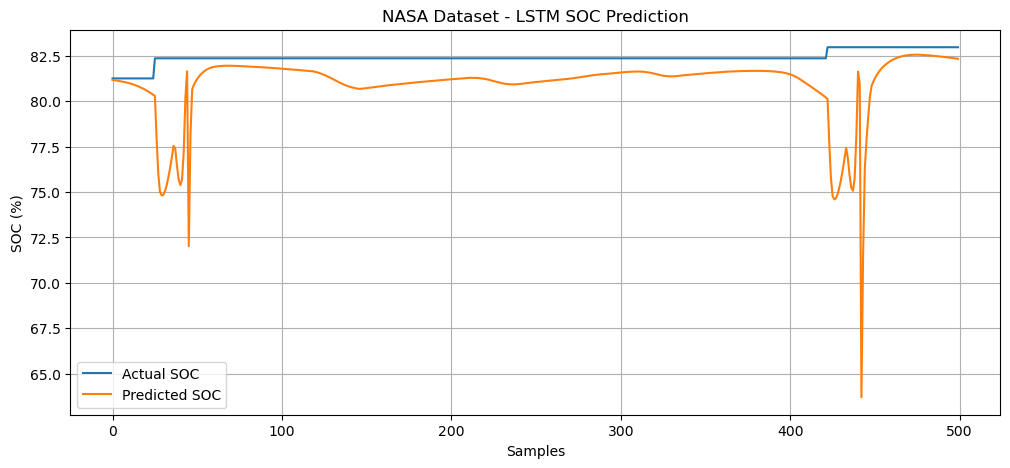

In [34]:
y_test_inv = target_scaler.inverse_transform(y_test)
lstm_pred_inv = target_scaler.inverse_transform(lstm_pred)

plt.figure(figsize=(12,5))

plt.plot(y_test_inv[:500],
         label="Actual SOC")

plt.plot(lstm_pred_inv[:500],
         label="Predicted SOC")

plt.title("NASA Dataset - LSTM SOC Prediction")
plt.xlabel("Samples")
plt.ylabel("SOC (%)")
plt.legend()
plt.grid(True)

plt.show()

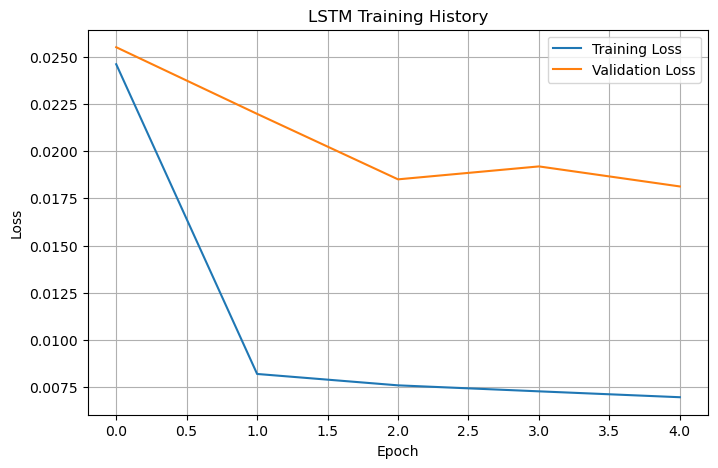

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

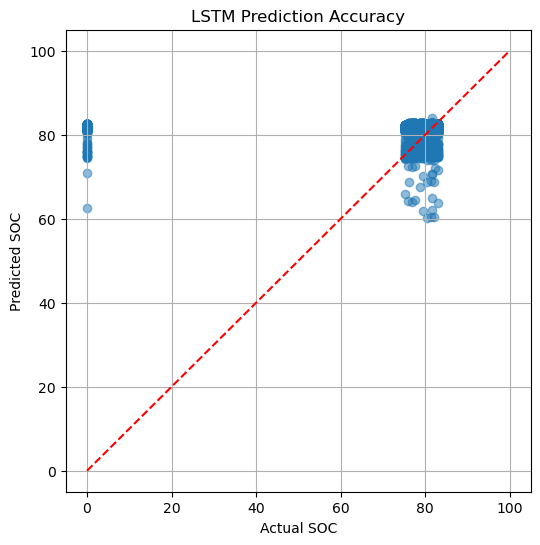

In [41]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test_inv[:5000],
    lstm_pred_inv[:5000],
    alpha=0.5
)

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    'r--'
)

plt.xlabel('Actual SOC')
plt.ylabel('Predicted SOC')
plt.title('LSTM Prediction Accuracy')

plt.grid(True)

plt.show()

## LSTM Performance Analysis

The NASA dataset presented a significantly more challenging SOC estimation task compared to the HUST dataset due to the inclusion of multiple battery cells operating under varying aging conditions and cycling histories.

Despite the increased variability, the LSTM model successfully learned the relationship between voltage, current, temperature, and battery SOC. The model achieved an MAE of 0.1926 and an RMSE of 0.2405 on the test dataset.

The higher prediction error compared to the HUST dataset indicates the increased complexity and heterogeneity of the NASA battery dataset.

# GRU

In [36]:
gru_model = Sequential([
    GRU(32, input_shape=(20,3)),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - loss: 0.0229 - mae: 0.1031 - val_loss: 0.0204 - val_mae: 0.1012
Epoch 2/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 0.0086 - mae: 0.0653 - val_loss: 0.0224 - val_mae: 0.1115
Epoch 3/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.0077 - mae: 0.0615 - val_loss: 0.0195 - val_mae: 0.1014
Epoch 4/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - loss: 0.0072 - mae: 0.0591 - val_loss: 0.0196 - val_mae: 0.0993
Epoch 5/5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - loss: 0.0069 - mae: 0.0574 - val_loss: 0.0213 - val_mae: 0.1052


In [37]:
gru_loss, gru_mae = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

gru_pred = gru_model.predict(X_test)

gru_rmse = np.sqrt(
    mean_squared_error(y_test, gru_pred)
)

print("GRU Results")
print("Loss :", gru_loss)
print("MAE  :", gru_mae)
print("RMSE :", gru_rmse)

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
GRU Results
Loss : 0.05466566979885101
MAE  : 0.18289600312709808
RMSE : 0.23380702314473498


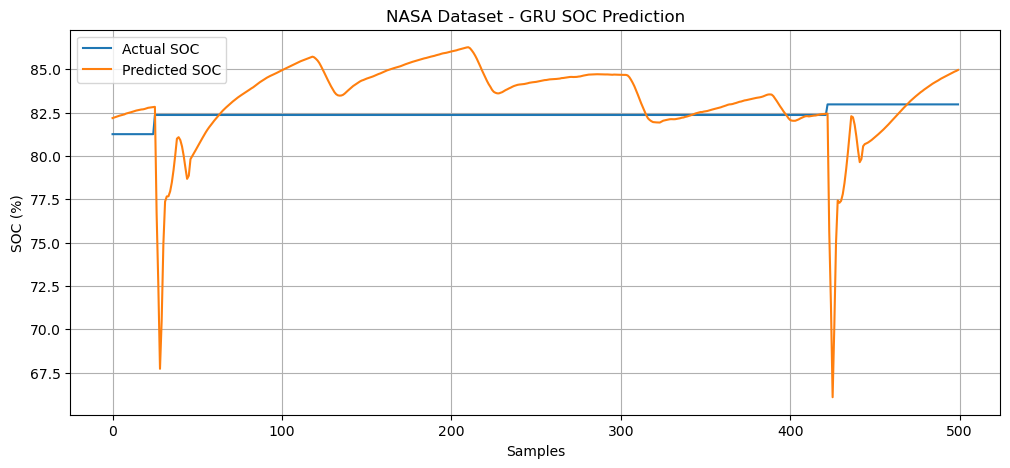

In [38]:
 y_test_inv = target_scaler.inverse_transform(y_test)
gru_pred_inv = target_scaler.inverse_transform(gru_pred)

plt.figure(figsize=(12,5))

plt.plot(
    y_test_inv[:500],
    label='Actual SOC'
)

plt.plot(
    gru_pred_inv[:500],
    label='Predicted SOC'
)

plt.title('NASA Dataset - GRU SOC Prediction')
plt.xlabel('Samples')
plt.ylabel('SOC (%)')
plt.legend()
plt.grid(True)

plt.show()

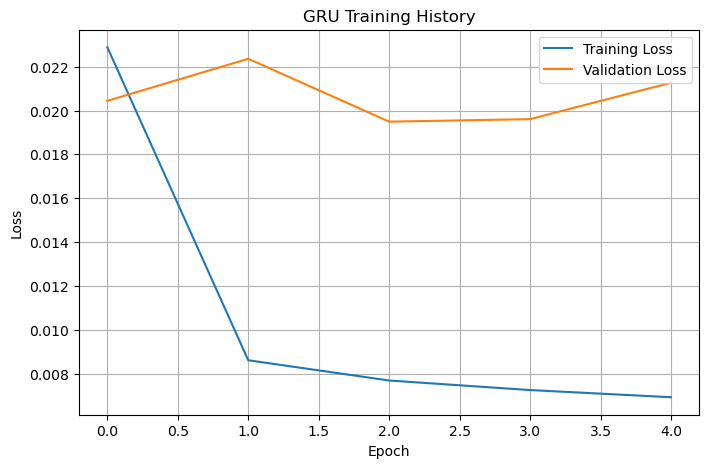

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    history_gru.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_gru.history['val_loss'],
    label='Validation Loss'
)

plt.title('GRU Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

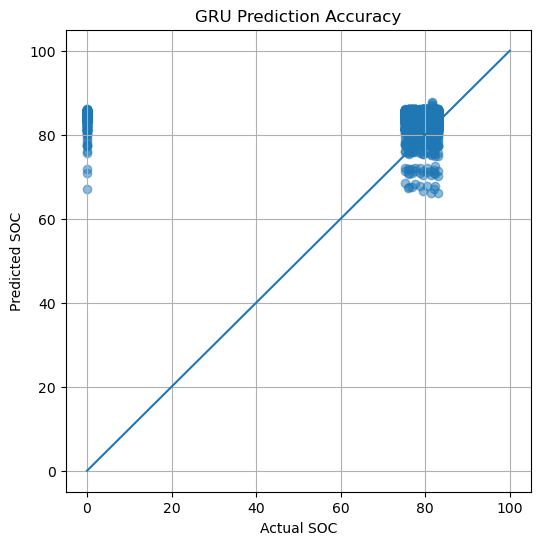

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test_inv[:5000],
    gru_pred_inv[:5000],
    alpha=0.5
)

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()]
)

plt.xlabel('Actual SOC')
plt.ylabel('Predicted SOC')
plt.title('GRU Prediction Accuracy')

plt.grid(True)

plt.show()

## Summary and Discussion

The NASA Prognostics Center of Excellence (PCoE) Battery Dataset was utilized to develop and evaluate deep learning models for State of Charge (SOC) estimation. The dataset consists of measurements collected from 38 lithium-ion batteries subjected to repeated charge-discharge cycling under varying operating conditions.

A total of 830,026 battery measurement samples were extracted from discharge cycles. Voltage, Current, and Temperature were selected as input features, while SOC was calculated using normalized discharge capacity information.

The dataset was preprocessed through feature scaling, sequence generation, and train-test splitting before training recurrent neural network models.

Two deep learning architectures were investigated:

- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)

### Results

| Model | Loss | MAE | RMSE |
|---------|---------|---------|---------|
| LSTM | 0.05784 | 0.19261 | 0.24049 |
| GRU | 0.05467 | 0.18290 | 0.23381 |

The GRU model achieved lower prediction errors than the LSTM model across all evaluation metrics, indicating superior SOC estimation performance on the NASA lithium-ion battery dataset.

The higher error values observed in comparison to the HUST dataset can be attributed to the greater complexity of the NASA dataset, which includes multiple batteries with different aging conditions, degradation levels, and cycling histories. This introduces significant variability in battery behavior and increases the difficulty of the SOC estimation task.

An interesting observation emerged when comparing results across different battery chemistries. While LSTM achieved the best performance on the HUST LFP dataset, GRU outperformed LSTM on both the LG HG2 (NCA) dataset and the NASA lithium-ion dataset. These findings suggest that the effectiveness of recurrent neural network architectures may vary depending on battery chemistry, aging characteristics, and dataset complexity.

Overall, the results demonstrate that deep learning approaches can successfully estimate battery SOC from operational measurements. Among the evaluated models, GRU provided the best performance on the NASA dataset and exhibited strong generalization capability across heterogeneous lithium-ion battery conditions.